<a href="https://colab.research.google.com/github/ayubarslaan/CO2-emission-analysis/blob/main/CO2_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 CO₂ Emissions Analysis and Forecasting
**Author:** Arslaan  
**Dataset:** Our World in Data CO₂ dataset

## Objective
Explore global CO₂-emission patterns since 2000, compare major emitters, and build a small linear-regression forecast for global annual emissions.

> **Note:** This forecast is educational. Emissions are influenced by policy, economics, energy transitions, and shocks, so a simple linear model should not be used for real-world planning.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (11, 6)

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data quality checks and preparation

In [2]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values in selected columns:")
print(df[['country', 'year', 'co2', 'co2_per_capita']].isna().sum())

df_cleaned = df.loc[df['year'] >= 2000, ['country', 'year', 'co2', 'co2_per_capita']].dropna()
print("\nCleaned dataset shape:", df_cleaned.shape)
df_cleaned.head()

Dataset shape: (50411, 79)
Duplicate rows: 0

Missing values in selected columns:
country               0
year                  0
co2               21027
co2_per_capita    23902
dtype: int64

Cleaned dataset shape: (5775, 4)


,country,year,co2,co2_per_capita
250,Afghanistan,2000,1.047,0.052
251,Afghanistan,2001,1.069,0.053
252,Afghanistan,2002,1.341,0.063
253,Afghanistan,2003,1.560,0.069
254,Afghanistan,2004,1.237,0.053


## 2. Top CO₂ emitters in the latest available year

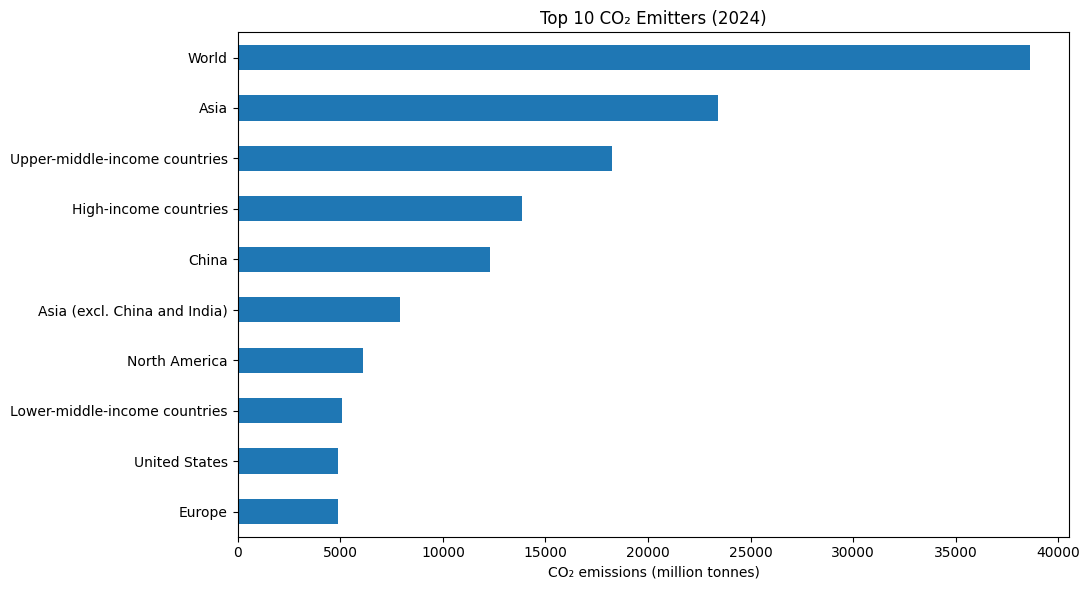

,country,co2
15267,Europe,4880.514
48007,United States,4904.120
27383,Lower-middle-income countries,5089.165
33835,North America,6084.276
3403,Asia (excl. China and India),7909.973
9933,China,12289.037
20669,High-income countries,13867.993
48282,Upper-middle-income countries,18237.494
2953,Asia,23392.488
49785,World,38598.578


In [3]:
latest_year = int(df_cleaned['year'].max())
top_emitters = (df_cleaned[df_cleaned['year'] == latest_year]
                .nlargest(10, 'co2')
                .sort_values('co2'))

ax = top_emitters.plot.barh(x='country', y='co2', legend=False)
ax.set_title(f'Top 10 CO₂ Emitters ({latest_year})')
ax.set_xlabel('CO₂ emissions (million tonnes)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

top_emitters[['country', 'co2']]

## 3. Trends for selected countries

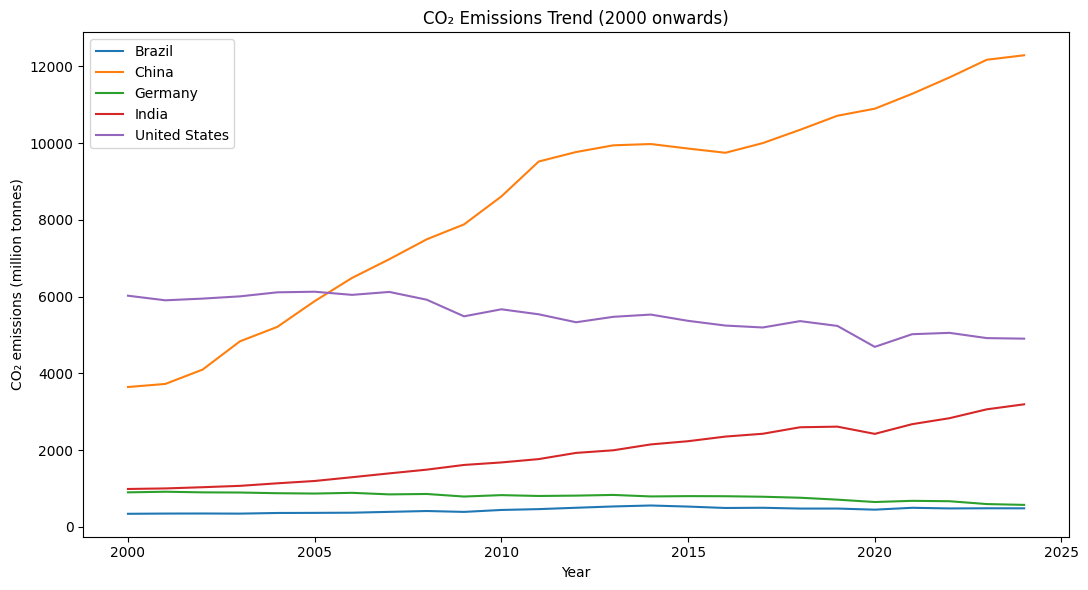

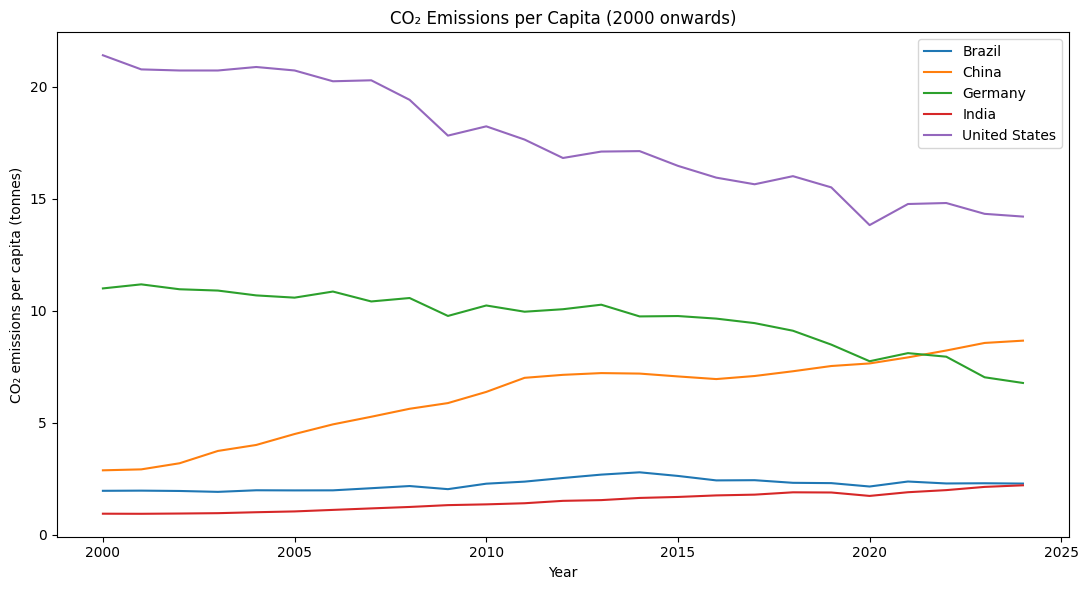

In [4]:
countries = ['United States', 'China', 'India', 'Germany', 'Brazil']
selected = df_cleaned[df_cleaned['country'].isin(countries)]

for country, group in selected.groupby('country'):
    plt.plot(group['year'], group['co2'], label=country)

plt.title('CO₂ Emissions Trend (2000 onwards)')
plt.xlabel('Year')
plt.ylabel('CO₂ emissions (million tonnes)')
plt.legend()
plt.tight_layout()
plt.show()

for country, group in selected.groupby('country'):
    plt.plot(group['year'], group['co2_per_capita'], label=country)

plt.title('CO₂ Emissions per Capita (2000 onwards)')
plt.xlabel('Year')
plt.ylabel('CO₂ emissions per capita (tonnes)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Small forecasting section: global CO₂ emissions

MAE: 2,804.54 million tonnes
R²: -4.638


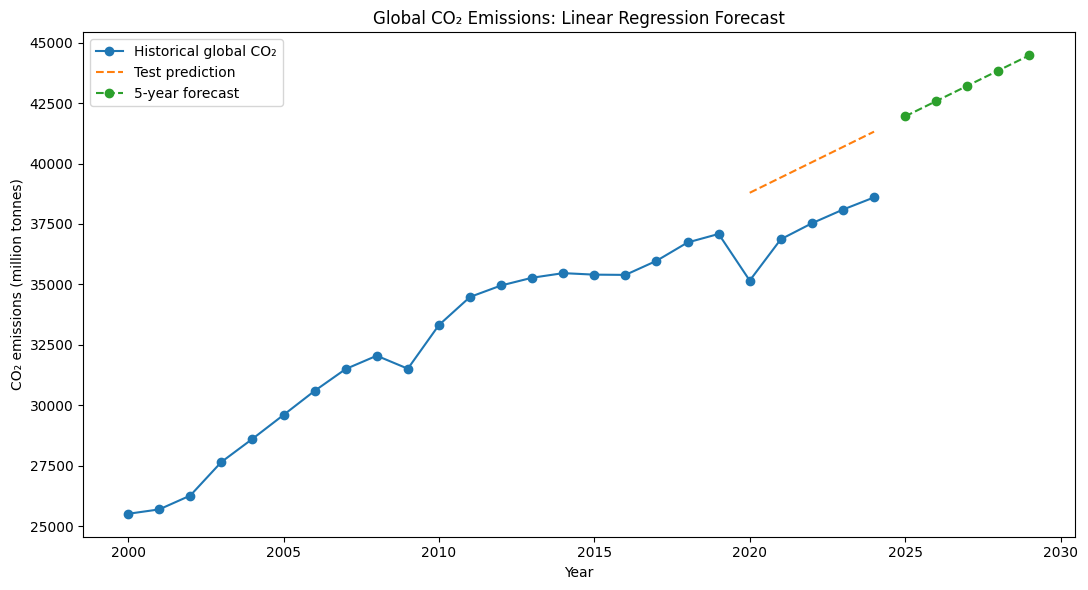

,year,forecast_co2_million_tonnes
0,2025,41949.63
1,2026,42581.63
2,2027,43213.63
3,2028,43845.63
4,2029,44477.63


In [5]:
# OWID's 'World' row represents global totals.
world = (df.loc[(df['country'] == 'World') & (df['year'] >= 2000), ['year', 'co2']]
         .dropna()
         .sort_values('year'))

# Time-aware split: earlier years for training, latest 20% for testing.
split = int(len(world) * 0.8)
train, test = world.iloc[:split], world.iloc[split:]

model = LinearRegression()
model.fit(train[['year']], train['co2'])

test_pred = model.predict(test[['year']])
print(f"MAE: {mean_absolute_error(test['co2'], test_pred):,.2f} million tonnes")
print(f"R²: {r2_score(test['co2'], test_pred):.3f}")

future_years = pd.DataFrame({'year': range(int(world.year.max()) + 1, int(world.year.max()) + 6)})
future_pred = model.predict(future_years)

plt.plot(world['year'], world['co2'], marker='o', label='Historical global CO₂')
plt.plot(test['year'], test_pred, linestyle='--', label='Test prediction')
plt.plot(future_years['year'], future_pred, marker='o', linestyle='--', label='5-year forecast')
plt.title('Global CO₂ Emissions: Linear Regression Forecast')
plt.xlabel('Year')
plt.ylabel('CO₂ emissions (million tonnes)')
plt.legend()
plt.tight_layout()
plt.show()

forecast = future_years.copy()
forecast['forecast_co2_million_tonnes'] = future_pred.round(2)
forecast

## 5. Conclusion and limitations
- Major emitters account for a large share of annual global CO₂ emissions.
- Total emissions and per-capita emissions tell different stories; both should be considered.
- The linear-regression forecast provides a transparent baseline, not a reliable policy forecast.
- Future improvements: add population, GDP, energy-mix features; compare time-series models; validate across multiple time windows.
